# Code for comparing predictions vs Simulations

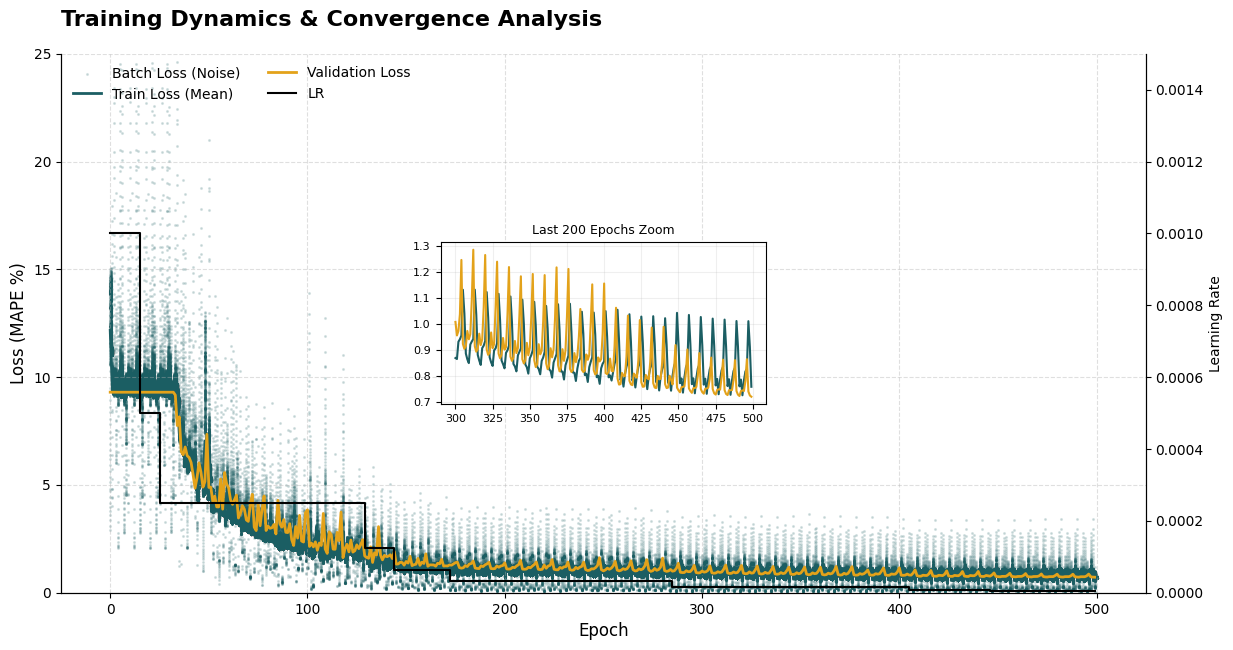

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1. CARGA Y LIMPIEZA
df_epoch = pd.read_csv('./ckpts_final_1_bacth_logs_EarlyStopping8/loss_media_por_epoch.csv')
df_batch = pd.read_csv('./ckpts_final_1_bacth_logs_EarlyStopping8/loss_por_batch.csv')
df_epoch.columns = df_epoch.columns.str.strip()
df_batch.columns = df_batch.columns.str.strip()

# Eje X continuo para batches
batches_per_epoch = df_batch[df_batch['epoch'] == 0]['batch'].max() + 1
df_batch['epoch_continuous'] = df_batch['epoch'] + (df_batch['batch'] / batches_per_epoch)

# 2. CONFIGURACIÓN
servicecolors = ["#1b5e63", "#e3a21a", "#d64541", "#7cb342", "#6d4c41"]
plt.rcParams['axes.prop_cycle'] = cycler(color=servicecolors)
plt.rcParams['font.family'] = 'sans-serif'

fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

# --- CAPA 1: BATCH LOSS (Puntos) ---
ax1.scatter(df_batch['epoch_continuous'], df_batch['loss_batch'], 
            color=servicecolors[0], s=1.5, alpha=0.15, label='Batch Loss (Noise)', zorder=1)

# --- CAPA 2: EPOCH LOSS (Líneas) ---
ax1.plot(df_epoch['epoch'], df_epoch['loss_media_train'], 
         color=servicecolors[0], linewidth=2, label='Train Loss (Mean)', zorder=3)

ax1.plot(df_epoch['epoch'], df_epoch['loss_val'], 
         color=servicecolors[1], linewidth=2, label='Validation Loss', zorder=4)

# --- CAPA 3: LEARNING RATE (Eje derecho) ---
ax2 = ax1.twinx()
ax2.step(df_epoch['epoch'], df_epoch['lr'], color='black', where='post', label='LR', zorder=2)
ax2.set_ylabel("Learning Rate", fontsize=10, color='black')
ax2.tick_params(axis='y', colors='black')
ax2.set_ylim(0, df_epoch['lr'].max() * 1.5)

# --- CAPA 4: ZOOM INSET (Mini-gráfica) ---
# Ubicación: 30% del tamaño, parte superior derecha
ax_ins = inset_axes(ax1, width="30%", height="30%", loc='center', borderpad=3)

# Datos del zoom (últimas 40 épocas)
tail_df = df_epoch.tail(200)
ax_ins.plot(tail_df['epoch'], tail_df['loss_media_train'], color=servicecolors[0], lw=1.5)
ax_ins.plot(tail_df['epoch'], tail_df['loss_val'], color=servicecolors[1], lw=1.5)

# Estilo del zoom
ax_ins.set_title("Last 200 Epochs Zoom", fontsize=9)
ax_ins.tick_params(labelsize=8)
ax_ins.grid(True, alpha=0.2)

# --- FINALIZACIÓN ---
ax1.set_title("Training Dynamics & Convergence Analysis", loc='left', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss (MAPE %)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_ylim(0, 25)

# Leyenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False, ncol=2)

# Quitar bordes (spines) innecesarios para un look moderno
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)



In [6]:
# -----------------------------
# Configuración
# -----------------------------
LEARNING_RATE = 0.001
TRAIN_PATH = "../final_set_dataset/oran-hqos_BW40_SCS30/train"
TEST_PATH = "../final_set_dataset/oran-hqos_BW40_SCS30/test"  # evaluamos sobre el mismo dataset para ver si memorizó
CKPT_DIR = "./ckpts_final_1_bacth_logs_EarlyStopping8/"
ZSCORE_PATH = "../final_set_dataset/oran-hqos_BW40_SCS30/zscore_stats2.json"

# -----------------------------

In [8]:

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import re
import numpy as np
import json
import tensorflow as tf
import matplotlib.pyplot as plt
servicecolors = [
    "#1b5e63",  
    "#e3a21a", 
    "#d64541",  
    "#7cb342",  
    "#6d4c41"  
]
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=servicecolors)
from data_generatorHQoS import input_fn
import sys
sys.path.append('../')
from delay_model_HQoS import RouteNet_Fermi

from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_normalization_stats(data_dirs: list):
    features_to_normalize = [
        'traffic', 'packets', 'eq_lambda', 'avg_pkts_lambda', 'exp_max_factor',
        'pkts_lambda_on', 'avg_t_off', 'avg_t_on', 'ar_a', 'sigma',
        'capacity', 'queue_size'
    ]
    stats = {feat: [] for feat in features_to_normalize}
    
    for data_dir in data_dirs:
        print(f"[*] Analizando datos en: {data_dir}")
        ds = input_fn(data_dir, shuffle=False)
        for inputs, _ in ds:
            for feat in features_to_normalize:
                if feat in inputs:
                    values = inputs[feat].numpy().flatten()
                    stats[feat].extend(values.tolist())
    
    z_score = {}
    for feat in features_to_normalize:
        if stats[feat]:
            mean_val = float(np.mean(stats[feat]))
            std_val = float(np.std(stats[feat]))
            
            # --- MEJORA: Si la desviación es 0, forzamos a 1 ---
            if std_val == 0:
                print(f" [!] Aviso: {feat} tiene desviación 0. Forzando a 1.0.")
                std_val = 1.0
            
            z_score[feat] = [mean_val, std_val]
        else:
            # Caso por defecto si no hay datos para esa feature
            z_score[feat] = [0.0, 1.0]
            
    return z_score


def update_model_z_score(model, z_score_dict):
    if not hasattr(model, 'z_score') or model.z_score is None:
        model.z_score = {}
    updates = {k: v for k, v in z_score_dict.items() if isinstance(v, list) and v[1] != 0}
    model.z_score.update(updates)
    print(f"✓ Z-Score actualizado para {len(updates)} campos.")



2026-05-04 15:33:06.448874: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-05-04 15:33:06.448900: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-05-04 15:33:06.448925: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (mu): /proc/driver/nvidia/version does not exist
2026-05-04 15:33:06.449200: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 15:33:06.630094: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimizatio

✓ Z-Score actualizado para 12 campos.
[*] Z-Score cargado y aplicado al modelo.
Mejor checkpoint encontrado: epoch_500_loss_0.7201
1408/1408 [==============================] - 21s 10ms/step
MAE: 0.000000
RMSE: 0.000002
MRE (%): 0.77%


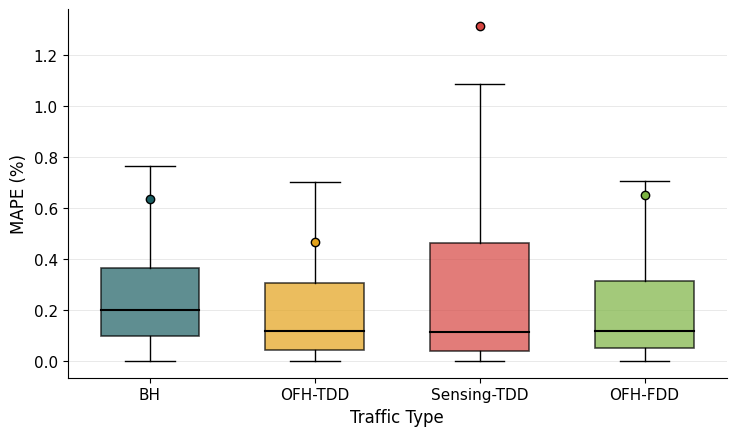

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import re
import os
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 1. Configuración del Modelo y Carga
# -----------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_object = tf.keras.losses.MeanAbsolutePercentageError()
model = RouteNet_Fermi()

zscore_path = ZSCORE_PATH
if zscore_path and os.path.exists(zscore_path):
    with open(zscore_path, 'r') as f:
        loaded_z_score = json.load(f)
    update_model_z_score(model, loaded_z_score)
    print("[*] Z-Score cargado y aplicado al modelo.")
else:
    print("[!] No se encontró Z-Score. Calculando...")
    z_score_stats = compute_normalization_stats([TRAIN_PATH, TEST_PATH])
    update_model_z_score(model, z_score_stats)
    with open(zscore_path, 'w') as f:
        json.dump(z_score_stats, f, indent=4)

model.compile(loss=loss_object, optimizer=optimizer, run_eagerly=False)

# Buscar mejor checkpoint
best = None
best_mre = float('inf')
for f in os.listdir(CKPT_DIR):
    if f.endswith(".index"):
        reg = re.findall(r"\d+\.\d+", f)
        if len(reg) > 0:
            mre = float(reg[0])
            if mre <= best_mre:
                best = f.replace('.index','')
                best_mre = mre

print(f"Mejor checkpoint encontrado: {best}")
model.load_weights(os.path.join(CKPT_DIR, best)).expect_partial()

# -----------------------------
# 2. Inferencia y Métricas
# -----------------------------
ds_test = input_fn(TEST_PATH, shuffle=False)
predictions = model.predict(ds_test, verbose=1).flatten()

real_delays = []
flow_names = []

# Extraer etiquetas reales y asignar nombres de flujos (ajusta según tu dataset)
for x, y in ds_test:
    y_val = y.numpy().flatten()
    real_delays.extend(y_val)
    # Aquí asignamos nombres según el índice del flujo en el batch
    for idx in range(len(y_val)):
        flow_names.append(f"f_{idx}")

real_delays = np.array(real_delays)
flow_names = np.array(flow_names)
errors = np.abs((real_delays - predictions) / real_delays) * 100

print(f"MAE: {mean_absolute_error(real_delays, predictions):.6f}")
print(f"RMSE: {np.sqrt(mean_squared_error(real_delays, predictions)):.6f}")
print(f"MRE (%): {np.mean(errors):.2f}%")

# -----------------------------
# 3. Gráfico Estilo "Paper"
# -----------------------------

# Estilo Global
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "CMU Sans Serif", "DejaVu Sans"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

unique_flows = np.unique(flow_names)
data_to_plot = [errors[flow_names == f] for f in unique_flows]


fig, ax = plt.subplots(figsize=(7.5, 4.5))

box = ax.boxplot(
    data_to_plot,
    labels=unique_flows,
    patch_artist=True,
    showmeans=True,
    meanline=False,   
    showfliers=False,
    widths=0.6
)

# Estética de las cajas
for i, patch in enumerate(box['boxes']):
    color = servicecolors[i % len(servicecolors)]
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

# Medianas y Medias
for median in box['medians']:
    median.set(color='black', linewidth=1.5)

for i, mean in enumerate(box['means']):
    color = servicecolors[i % len(servicecolors)]
    mean.set(marker='o', markerfacecolor=color, markeredgecolor="black", markersize=6, linestyle='none')

# Bigotes y Caps
for whisker in box['whiskers']:
    whisker.set(color='black', linewidth=1)
for cap in box['caps']:
    cap.set(color='black', linewidth=1)

# Refinamiento de Ejes
ax.grid(axis='y', linestyle='-', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("Traffic Type")

# IMPORTANTE: Ajusta estos nombres según el orden de tus flujos reales
# Si tienes 4 tipos de tráfico:
if len(unique_flows) == 4:
    ax.set_xticklabels(["BH", "OFH-TDD", "Sensing-TDD", "OFH-FDD"])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


--- GLOBAL METRICS (Scaled to µs) ---
Global MAPE: 0.767% | Global MAE: 0.320 µs | Global RMSE: 2.193 µs | Global R^2: 0.9604

--- METRICS BY TRAFFIC TYPE ---
Traffic Type  MAPE  MAE (µs)  RMSE (µs)     R2
          BH 0.634     0.198      1.056 0.9880
     OFH-TDD 0.467     0.181      1.476 0.9808
 Sensing-TDD 1.314     0.584      3.023 0.9317
     OFH-FDD 0.653     0.316      2.610 0.9499
Archivo 'metrics.csv' generado con éxito.

--- GLOBAL METRICS (Scaled to µs) ---
Global MAPE: 0.767% | Global MAE: 0.320 µs | Global RMSE: 2.193 µs | Global R^2: 0.9604

--- METRICS BY TRAFFIC TYPE ---
Traffic Type  MAPE  MAE (µs)  RMSE (µs)     R2
          BH 0.634     0.198      1.056 0.9880
     OFH-TDD 0.467     0.181      1.476 0.9808
 Sensing-TDD 1.314     0.584      3.023 0.9317
     OFH-FDD 0.653     0.316      2.610 0.9499


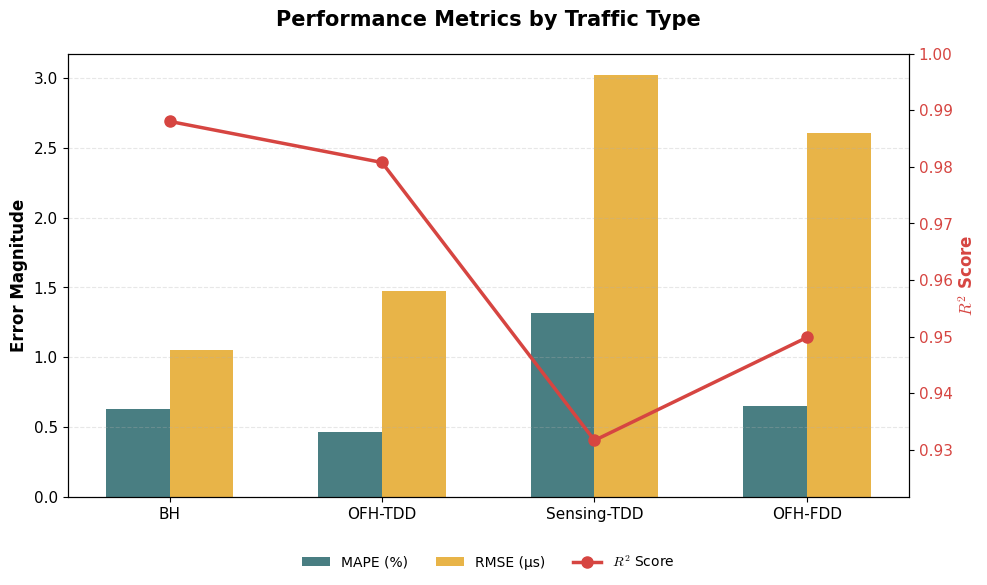

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


SCALE = 1e6  


mae_val = mean_absolute_error(real_delays, predictions) * SCALE
rmse_val = np.sqrt(mean_squared_error(real_delays, predictions)) * SCALE
r2_val = r2_score(real_delays, predictions)
mape_val = np.mean(np.abs((real_delays - predictions) / np.maximum(real_delays, 1e-9))) * 100

traffic_metrics = []
name_map = {"f_0": "BH", "f_1": "OFH-TDD", "f_2": "Sensing-TDD", "f_3": "OFH-FDD"}

labels = []
mape_list = []
rmse_list = []
r2_list = []

for flow_type in unique_flows:
    mask = (flow_names == flow_type)
    y_true = real_delays[mask]
    y_pred = predictions[mask]
    
    m_mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-9))) * 100
    m_mae = mean_absolute_error(y_true, y_pred) * SCALE
    m_rmse = np.sqrt(mean_squared_error(y_true, y_pred)) * SCALE
    m_r2 = r2_score(y_true, y_pred)
    
  
    t_name = name_map.get(flow_type, flow_type)
    
    
    traffic_metrics.append({
        "Traffic Type": t_name,
        "MAPE": round(m_mape, 3),
        "MAE (µs)": round(m_mae, 3),
        "RMSE (µs)": round(m_rmse, 3),
        "R2": round(m_r2, 4)
    })
    
    # Guardar para Gráfica
    labels.append(t_name)
    mape_list.append(m_mape)
    rmse_list.append(m_rmse)
    r2_list.append(m_r2)


df_metrics = pd.DataFrame(traffic_metrics)

print("\n--- GLOBAL METRICS (Scaled to µs) ---")
print(f"Global MAPE: {mape_val:.3f}% | Global MAE: {mae_val:.3f} µs | Global RMSE: {rmse_val:.3f} µs | Global R^2: {r2_val:.4f}")
print("\n--- METRICS BY TRAFFIC TYPE ---")
print(df_metrics.to_string(index=False))

df_metrics.to_csv('metrics.csv', index=False)

print(f"Archivo 'metrics.csv' generado con éxito.")
print("\n--- GLOBAL METRICS (Scaled to µs) ---")
print(f"Global MAPE: {mape_val:.3f}% | Global MAE: {mae_val:.3f} µs | Global RMSE: {rmse_val:.3f} µs | Global R^2: {r2_val:.4f}")
print("\n--- METRICS BY TRAFFIC TYPE ---")
print(df_metrics.to_string(index=False))


x = np.arange(len(labels))
width = 0.3

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bars (MAPE y RMSE)
bar_mape = ax1.bar(x - width/2, mape_list, width, label='MAPE (%)', color='#1b5e63', alpha=0.8)
bar_rmse = ax1.bar(x + width/2, rmse_list, width, label='RMSE (µs)', color='#e3a21a', alpha=0.8)

ax1.set_ylabel('Error Magnitude', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# R2
ax2 = ax1.twinx()
line_r2 = ax2.plot(x, r2_list, color='#d64541', marker='o', linewidth=2.5, markersize=8, label='$R^2$ Score')
ax2.set_ylabel('$R^2$ Score', fontsize=12, color='#d64541', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d64541')
ax2.set_ylim(min(r2_list) - 0.01, 1.0) 


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)

plt.title('Performance Metrics by Traffic Type', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

/home/administrator/GNN-Xhaul/venv/lib/python3.7/site-packages/ipykernel_launcher.py:76: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


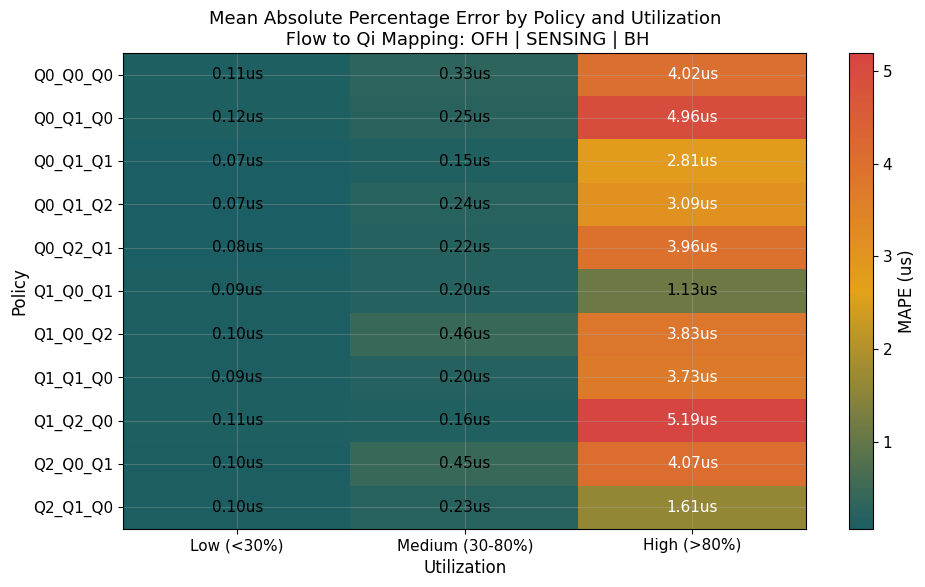

In [16]:
import tarfile
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from cycler import cycler
from data_generatorHQoS import input_fn

# servicecolors = [
#     "#1b5e63",  # Petróleo/Verde oscuro
#     "#e3a21a",  # Ámbar/Dorado
#     "#d64541",  # Carmín/Rojo
#     "#7cb342",  # Manzana/Verde
#     "#6d4c41"   # Marrón/Tierra
# ]
# plt.rcParams['axes.prop_cycle'] = cycler(color=servicecolors)
# plt.rcParams['grid.alpha'] = 0.3
# plt.rcParams['axes.grid'] = True

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = Path("../final_set_dataset/oran-hqos_BW40_SCS30/test")
TAR_FILE = BASE_PATH / "batch_0000.tar.gz"

# 1. LEER DESCRIPTOR DESDE EL TAR
with tarfile.open(TAR_FILE, "r:gz") as tar:
    member = [m for m in tar.getmembers() if "descriptor.txt" in m.name][0]
    f = tar.extractfile(member)
    desc_df = pd.read_csv(io.BytesIO(f.read()), sep=';', header=None, names=['idx', 'scenario_full'])

def get_policy(s):
    m = re.search(r"(Q\d+_Q\d+_Q\d+)", s)
    return m.group(1) if m else "UNK"

def get_utilization_cat(s):
    m = re.search(r"UTIL(\d+\.\d+)", s)
    if m:
        val = float(m.group(1))
        if val < 30: return "Low (<30%)"
        elif val < 80: return "Medium (30-80%)"
        else: return "High (>80%)"
    return "Unknown"

# 2. PROCESAR DATOS
rows = []
cursor = 0
for i, (_, y) in enumerate(input_fn(str(BASE_PATH), shuffle=False)):
    y_real = y.numpy().flatten()
    y_pred = predictions[cursor:cursor + len(y_real)]
    scen_full = desc_df.iloc[i]['scenario_full'] if i < len(desc_df) else "unknown"
    
    pol = get_policy(scen_full)
    util_cat = get_utilization_cat(scen_full)

    for r, p in zip(y_real, y_pred):
        rows.append({
            "scenario": scen_full, "policy": pol, "utilization": util_cat,
            "real": r * 1e6, "pred": p * 1e6,
            "err": abs(r - p) * 1e6, "perc_err": (abs(r - p) / r * 100) if r != 0 else 0
        })
    cursor += len(y_real)

df = pd.DataFrame(rows)

# --- GRÁFICA 1: HEATMAP (Usando una variante de tus colores para el degradado) ---
pivot = df.groupby(["policy", "utilization"])["perc_err"].mean().unstack()
cols_order = [c for c in ["Low (<30%)", "Medium (30-80%)", "High (>80%)"] if c in pivot.columns]
pivot = pivot[cols_order]

plt.figure(figsize=(10, 6))
from matplotlib.colors import LinearSegmentedColormap
my_cmap = LinearSegmentedColormap.from_list("service_map", [servicecolors[0], servicecolors[1], servicecolors[2]])

im = plt.imshow(pivot, aspect="auto", cmap=my_cmap)
plt.colorbar(im, label="MAPE (us)")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        plt.text(j, i, f"{val:.2f}us", ha="center", va="center", color="white" if val > pivot.values.mean() else "black")

plt.xlabel("Utilization")
plt.ylabel("Policy")

# Título con categoría incluida
plt.title("Mean Absolute Percentage Error by Policy and Utilization\n Flow to Qi Mapping: OFH | SENSING | BH")
plt.tight_layout()



In [ ]:
import re
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# Extraction Functions
# ==========================================
def get_graph_type(s):
    # Extrae lo que hay entre 'graph_' y '_ALL' (ej: SPGraph, SPWRRGraph_10_90)
    m = re.search(r"graph_(.*?)_ALL", s)
    return m.group(1) if m else "Unknown"

def get_policy(s):
    # Extrae el mapeo de colas (ej: Q0_Q1_Q2)
    m = re.search(r"(Q\d+_Q\d+_Q\d+)", s)
    return m.group(1) if m else "UNK"

# ==========================================
# Apply Extraction to DataFrame
# ==========================================

df['scheduler'] = df['scenario'].apply(get_graph_type)
df['policy'] = df['scenario'].apply(get_policy)

# ==========================================
# Obtain measures for each group
# ==========================================
def scientific_metrics(group):
    r = group['real']
    p = group['pred']
    return pd.Series({
        'R2_Score': r2_score(r, p),
        'MAPE_%': (np.abs(r - p) / r).mean() * 100,
        'MAE_us': mean_absolute_error(r, p),
        'Count': len(r)
    })


table_scheduler = df.groupby('scheduler').apply(scientific_metrics).reset_index()
table_scheduler = table_scheduler.sort_values(by='R2_Score', ascending=False)

table_policy = df.groupby('policy').apply(scientific_metrics).reset_index()
table_policy = table_policy.sort_values(by='R2_Score', ascending=False)


print("\n" + "="*70)
print("   TABLE 1: PERFORMANCE BY SCHEDULER TYPE (SP vs WRR)")
print("="*70)
print(table_scheduler.round(4).to_string(index=False))

print("\n" + "="*70)
print("   TABLE 2: PERFORMANCE BY QoS MAPPING POLICY")
print("="*70)
print(table_policy.round(4).to_string(index=False))

# --- MÉTRICA GLOBAL FINAL PARA EL ABSTRACT DEL PAPER ---
global_r2 = r2_score(df['real'], df['pred'])
global_mape = (np.abs(df['real'] - df['pred']) / df['real']).mean() * 100
print(f"\n[!] GLOBAL: Mean R2 = {global_r2:.4f} | Mean MAPE = {global_mape:.2f}%")


   TABLE 1: PERFORMANCE BY SCHEDULER TYPE (SP vs WRR)
       scheduler  R2_Score  MAPE_%  MAE_us  Count
SPWRRGraph_40_60    0.9926  0.6861  0.2322  696.0
SPWRRGraph_30_70    0.9841  0.6517  0.2392  692.0
SPWRRGraph_60_40    0.9824  0.7128  0.2887  704.0
SPWRRGraph_90_10    0.9718  0.6273  0.2524  696.0
SPWRRGraph_50_50    0.9702  0.8403  0.3452  744.0
SPWRRGraph_70_30    0.9558  0.6985  0.2887  672.0
         SPGraph    0.9435  0.8959  0.3684  732.0
SPWRRGraph_10_90    0.8975  1.0078  0.5367  696.0

   TABLE 2: PERFORMANCE BY QoS MAPPING POLICY
  policy  R2_Score  MAPE_%  MAE_us  Count
Q1_Q0_Q1    0.9992  0.3547  0.0960  516.0
Q2_Q1_Q0    0.9943  0.4450  0.1599  556.0
Q1_Q0_Q2    0.9902  0.8463  0.2701  484.0
Q0_Q0_Q0    0.9876  0.9181  0.3095  480.0
Q0_Q1_Q1    0.9859  0.6138  0.2360  464.0
Q0_Q1_Q2    0.9760  0.9414  0.3308  508.0
Q2_Q0_Q1    0.9741  0.8556  0.3050  496.0
Q0_Q2_Q1    0.9737  0.7659  0.2589  592.0
Q0_Q1_Q0    0.9462  0.8631  0.3797  524.0
Q1_Q1_Q0    0.9428  0.7610  

/home/administrator/GNN-Xhaul/venv/lib/python3.7/site-packages/ipykernel_launcher.py:69: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


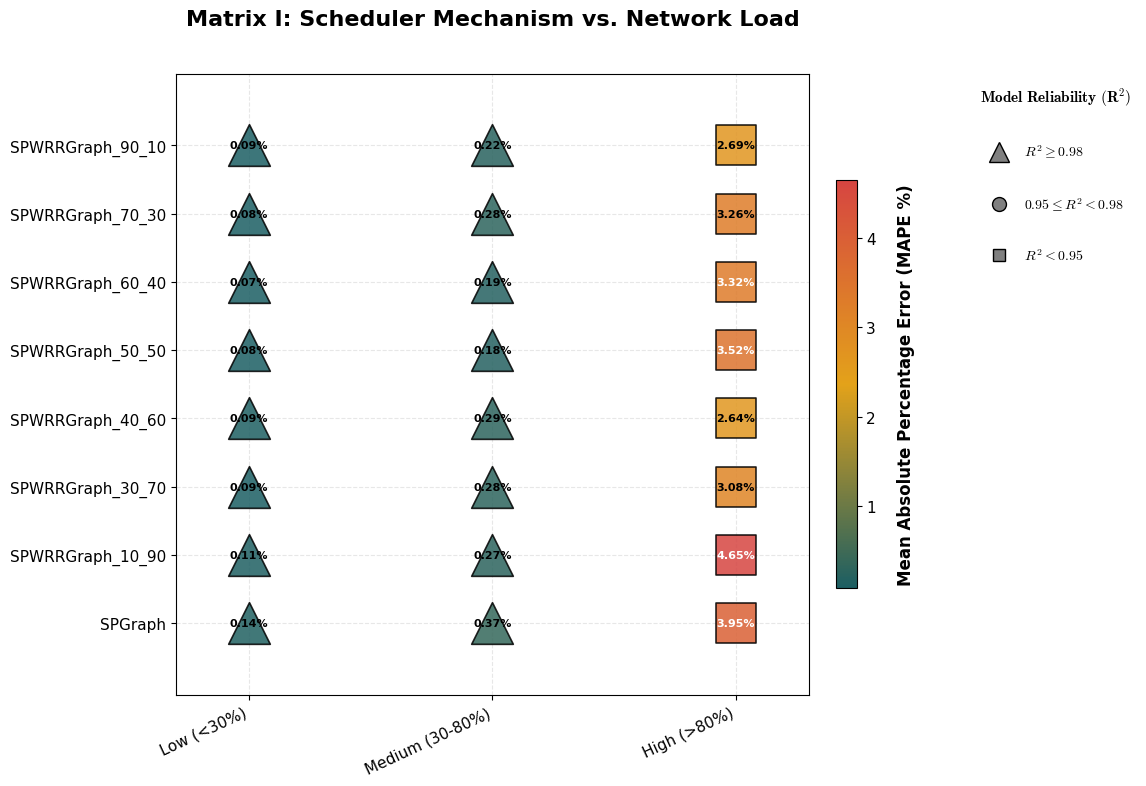

/home/administrator/GNN-Xhaul/venv/lib/python3.7/site-packages/ipykernel_launcher.py:69: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


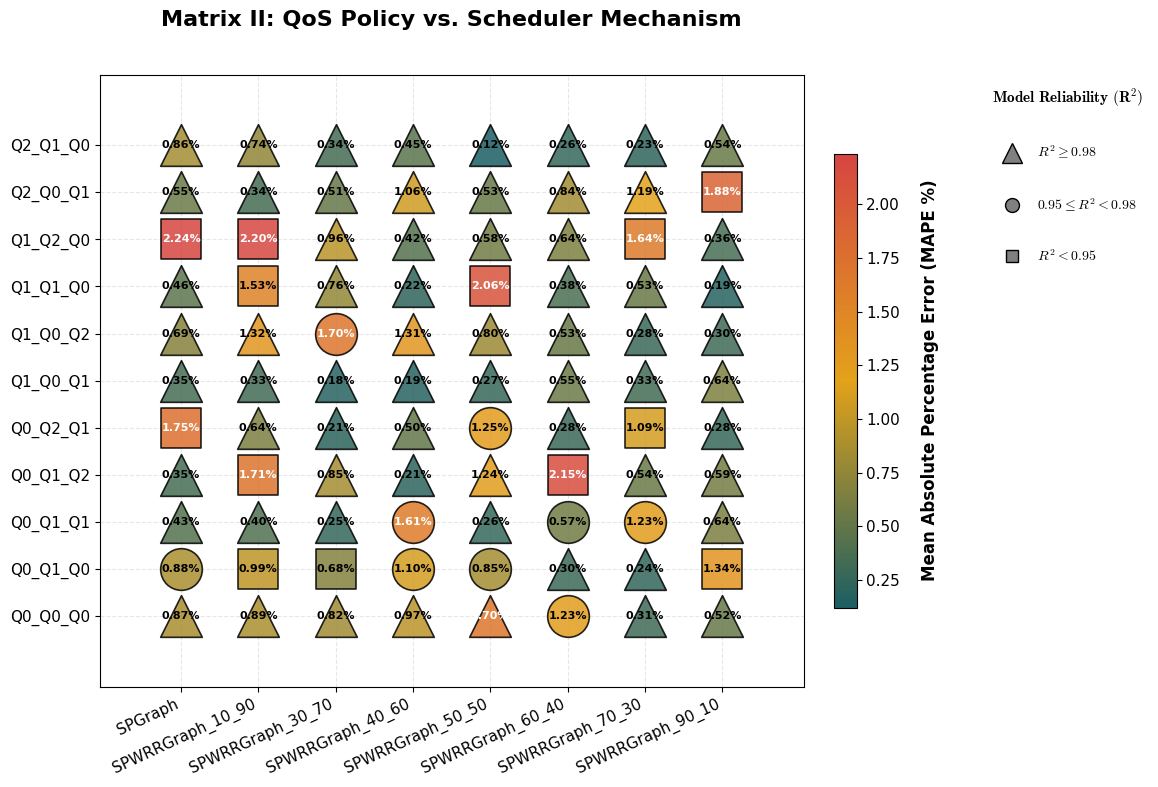

/home/administrator/GNN-Xhaul/venv/lib/python3.7/site-packages/ipykernel_launcher.py:69: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


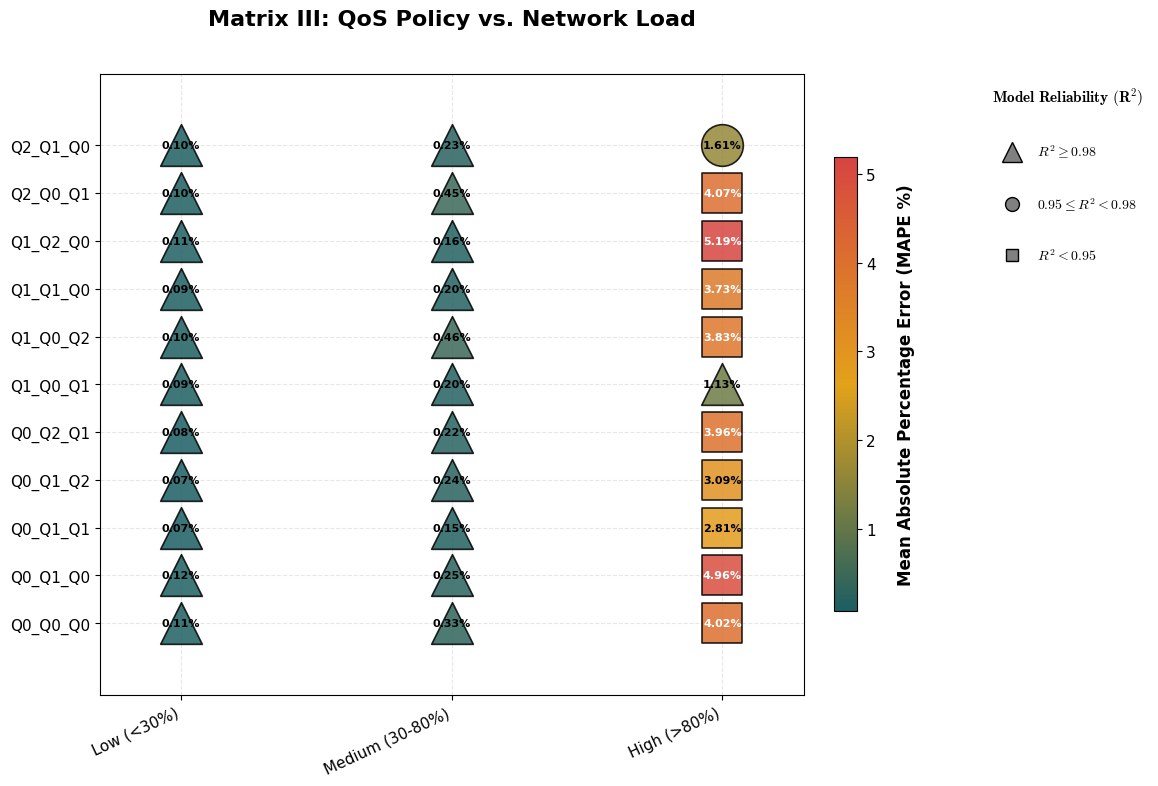

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score


def draw_paper_bubble_matrix(df_plot, x_col, y_col, title, x_order=None):
   
    def get_stats(group):
        r, p = group['real'], group['pred']
        mape = np.mean(np.abs((r - p) / np.maximum(r, 1e-9))) * 100
        r2 = r2_score(r, p) if len(r) > 1 else 0
        return pd.Series({'MAPE': mape, 'R2': r2})

    stats = df_plot.groupby([x_col, y_col]).apply(get_stats).reset_index()
    
   
    x_labels = x_order if x_order else sorted(stats[x_col].unique())
    y_labels = sorted(stats[y_col].unique())
    x_map = {val: i for i, val in enumerate(x_labels)}
    y_map = {val: i for i, val in enumerate(y_labels)}
    
   
    colors = ["#1b5e63", "#e3a21a", "#d64541"]
    custom_cmap = LinearSegmentedColormap.from_list("paper_map", colors)
    norm = Normalize(vmin=stats['MAPE'].min(), vmax=stats['MAPE'].max())

    fig, ax = plt.subplots(figsize=(12, 8))
    
  
    for i in range(len(stats)):
        row = stats.iloc[i]
        r2, mape = row['R2'], row['MAPE']
        x, y = x_map[row[x_col]], y_map[row[y_col]]
        
        if r2 >= 0.98:
            m, s = '^', 900
        elif r2 >= 0.95:
            m, s = 'o', 900
        else:
            m, s = 's', 800
            
        facecolor = custom_cmap(norm(mape))
        ax.scatter(x, y, s=s, color=facecolor, marker=m, 
                   alpha=0.85, edgecolors="black", linewidth=1.2, zorder=3)
        
        text_color = 'white' if norm(mape) > 0.7 else 'black'
        ax.text(x, y, f"{mape:.2f}%", ha='center', va='center', 
                fontsize=8, fontweight='bold', color=text_color, zorder=4)

   
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=25, ha="right")
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=35)
    
    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    
    
    ax.margins(0.15)
    

    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    
    sm.set_array([]) 
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('Mean Absolute Percentage Error (MAPE %)', fontweight='bold', labelpad=15)


    legend_elements = [
        Line2D([0], [0], marker='^', color='w', label=r'$R^2 \geq 0.98$', 
               markerfacecolor='gray', markersize=14, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label=r'$0.95 \leq R^2 < 0.98$ ', 
               markerfacecolor='gray', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='s', color='w', label=r'$R^2 < 0.95$', 
               markerfacecolor='gray', markersize=9, markeredgecolor='black')
    ]
    
    ax.legend(handles=legend_elements, title=r"$\mathbf{Model\ Reliability\ (R^2)}$", 
              loc="upper left", bbox_to_anchor=(1.25, 1), frameon=False, 
              labelspacing=2.5, title_fontsize=11)

    plt.tight_layout()
    plt.show()
    



u_order = ["Low (<30%)", "Medium (30-80%)", "High (>80%)"]

# Matrix I: Scheduler vs Utilization
draw_paper_bubble_matrix(df, 'utilization', 'scheduler', 
                         "Matrix I: Scheduler Mechanism vs. Network Load", 
                         x_order=u_order)

# Matrix II: QoS Policy vs Scheduler
draw_paper_bubble_matrix(df, 'scheduler', 'policy', 
                         "Matrix II: QoS Policy vs. Scheduler Mechanism")

# Matrix III: QoS Policy vs Utilization
draw_paper_bubble_matrix(df, 'utilization', 'policy', 
                         "Matrix III: QoS Policy vs. Network Load", 
                         x_order=u_order)


